<a href="https://colab.research.google.com/github/wajd-mq/wajd-mq/blob/main/Medical_NER_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kagglehub transformers datasets seqeval torch pandas numpy scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=0ab6734fb4d140601ec437407331be81b0140322beb3d3df277171915bcabf93
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
# ============================================================
# Medical NER - Full Pipeline with Pretrained Model
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings("ignore")

# ── 1. Download Dataset ──────────────────────────────────────
import kagglehub

path = kagglehub.dataset_download("finalepoch/medical-ner")
print("Path to dataset files:", path)
print("Files found:", os.listdir(path))


100%|██████████| 26.2k/26.2k [00:00<00:00, 4.34MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/finalepoch/medical-ner/versions/5
Files found: ['Corona2.json']


In [ ]:
# ── 2. Load & Explore Data ────────────────────────────────────
import glob

# البحث عن ملفات الداتا
json_files = glob.glob(os.path.join(path, "**/*.json"), recursive=True)
txt_files  = glob.glob(os.path.join(path, "**/*.txt"),  recursive=True)
csv_files  = glob.glob(os.path.join(path, "**/*.csv"),  recursive=True)

print("JSON files:", json_files)
print("TXT files:",  txt_files)
print("CSV files:",  csv_files)

# قراءة الداتا (Medical NER dataset)
# الداتا عادةً تكون بصيغة JSON
def load_medical_ner_data(path):
    data = []
    for f in glob.glob(os.path.join(path, "**/*.json"), recursive=True):
        with open(f, "r", encoding="utf-8") as fp:
            content = json.load(fp)
            if isinstance(content, list):
                data.extend(content)
            else:
                data.append(content)
    return data

raw_data = load_medical_ner_data(path)
print(f"\nTotal samples loaded: {len(raw_data)}")
print("\nSample entry:")
print(json.dumps(raw_data[0], indent=2))


JSON files: ['/root/.cache/kagglehub/datasets/finalepoch/medical-ner/versions/5/Corona2.json']
TXT files: []
CSV files: []

Total samples loaded: 1

Sample entry:
{
  "examples": [
    {
      "id": "18c2f619-f102-452f-ab81-d26f7e283ffe",
      "content": "While bismuth compounds (Pepto-Bismol) decreased the number of bowel movements in those with travelers' diarrhea, they do not decrease the length of illness.[91] Anti-motility agents like loperamide are also effective at reducing the number of stools but not the duration of disease.[8] These agents should be used only if bloody diarrhea is not present.[92]\n\nDiosmectite, a natural aluminomagnesium silicate clay, is effective in alleviating symptoms of acute diarrhea in children,[93] and also has some effects in chronic functional diarrhea, radiation-induced diarrhea, and chemotherapy-induced diarrhea.[45] Another absorbent agent used for the treatment of mild diarrhea is kaopectate.\n\nRacecadotril an antisecretory medication may be

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings("ignore")

# ── 3. Parse Dataset into BIO Format ─────────────────────────
"""
الداتا فيها:
  - text: النص الطبي
  - entities: list من (start, end, label)
نحولها إلى tokens + BIO tags
"""

def convert_to_bio(sample):
    """
    تحويل النص مع annotations إلى BIO tagging format
    """
    text     = sample.get("text", sample.get("content", ""))
    entities = sample.get("entities", sample.get("annotations", []))

    # ترتيب الـ entities حسب start position
    sorted_ents = sorted(entities, key=lambda x: x[0] if isinstance(x, list) else x["start"])

    tokens = []
    labels = []
    i = 0

    for ent in sorted_ents:
        # دعم صيغتين مختلفتين للداتا
        if isinstance(ent, list):
            start, end, label = ent[0], ent[1], ent[2]
        else:
            start = ent.get("start", ent.get("begin", 0))
            end   = ent.get("end", ent.get("stop", 0))
            label = ent.get("label", ent.get("type", "ENT"))

        # الكلمات قبل الـ entity
        if i < start:
            pre_text = text[i:start]
            for word in pre_text.split():
                if word.strip():
                    tokens.append(word.strip())
                    labels.append("O")

        # كلمات الـ entity نفسها
        ent_text = text[start:end]
        ent_words = ent_text.split()
        for idx, word in enumerate(ent_words):
            if word.strip():
                tokens.append(word.strip())
                tag = f"B-{label}" if idx == 0 else f"I-{label}"
                labels.append(tag)

        i = end

    # ما تبقى من النص
    remaining = text[i:].split()
    for word in remaining:
        if word.strip():
            tokens.append(word.strip())
            labels.append("O")

    return {"tokens": tokens, "labels": labels}


# تحويل كل الداتا
all_samples = []
for item in raw_data:
    if "examples" in item and isinstance(item["examples"], list):
        all_samples.extend(item["examples"])
    elif item.get("text") or item.get("content"):
        all_samples.append(item)

processed_data = [convert_to_bio(s) for s in all_samples if s.get("text") or s.get("content")]
processed_data = [d for d in processed_data if len(d["tokens"]) > 0]

print(f"Processed samples: {len(processed_data)}")
print("\nExample:")
ex = processed_data[0]
for tok, lab in zip(ex["tokens"][:15], ex["labels"][:15]):
    print(f"  {tok:<20} {lab}")

Processed samples: 31

Example:
  While                O
  bismuth              B-ENT
  compounds            I-ENT
  (                    O
  Pepto-Bismol         B-ENT
  )                    O
  decreased            O
  the                  O
  number               O
  of                   O
  bowel                O
  movements            O
  in                   O
  those                O
  with                 O


In [ ]:
# ── 4. Label Statistics ───────────────────────────────────────
all_labels = []
for d in processed_data:
    all_labels.extend(d["labels"])

label_counts = Counter(all_labels)
print("\nLabel distribution:")
for lab, cnt in label_counts.most_common():
    print(f"  {lab:<25} {cnt:>6}")

# استخراج قائمة الـ labels الفريدة
unique_labels = sorted(set(all_labels))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label  = {i: l for l, i in label2id.items()}
num_labels = len(unique_labels)

print(f"\nUnique labels ({num_labels}): {unique_labels}")



Label distribution:
  O                           2890
  B-ENT                        294
  I-ENT                        205

Unique labels (3): ['B-ENT', 'I-ENT', 'O']


In [ ]:
# ── 5. Train/Val/Test Split ───────────────────────────────────
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(processed_data, test_size=0.2,  random_state=42)
val_data,   test_data = train_test_split(temp_data,       test_size=0.5, random_state=42)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")


Train: 24 | Val: 3 | Test: 4


In [ ]:
# ── 6. Tokenizer & Dataset Class ─────────────────────────────
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.utils.data import Dataset, DataLoader
import torch

# نستخدم BioBERT لأنه متخصص بالنصوص الطبية
MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
# بديل: "allenai/scibert_scivocab_cased" أو "bert-base-cased"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class NERDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, max_length=256):
        self.data       = data
        self.tokenizer  = tokenizer
        self.label2id   = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample  = self.data[idx]
        tokens  = sample["tokens"]
        labels  = sample["labels"]

        # Tokenize مع الحفاظ على alignment مع الـ labels
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )

        word_ids     = encoding.word_ids()
        label_ids    = []
        previous_wid = None

        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)           # [CLS], [SEP], [PAD]
            elif wid != previous_wid:
                # أول subword للكلمة
                lbl = labels[wid] if wid < len(labels) else "O"
                label_ids.append(self.label2id.get(lbl, self.label2id["O"]))
            else:
                # subword لاحقة: نستخدم I- بدلاً من B- أو -100
                lbl = labels[wid] if wid < len(labels) else "O"
                if lbl.startswith("B-"):
                    lbl = "I-" + lbl[2:]
                label_ids.append(self.label2id.get(lbl, self.label2id.get("O", -100)))
            previous_wid = wid

        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(label_ids, dtype=torch.long),
        }


# إنشاء الـ datasets
train_dataset = NERDataset(train_data, tokenizer, label2id)
val_dataset   = NERDataset(val_data,   tokenizer, label2id)
test_dataset  = NERDataset(test_data,  tokenizer, label2id)

# DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Loading tokenizer: dmis-lab/biobert-base-cased-v1.2


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Train batches: 2 | Val: 1 | Test: 1


In [ ]:
# ── 7. Load Pretrained Model ──────────────────────────────────
from transformers import AutoModelForTokenClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {train_params:,}")


Using device: cuda


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	

Total parameters:     107,721,987
Trainable parameters: 107,721,987


In [ ]:
# ── 8. Optimizer & Scheduler ─────────────────────────────────
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps} | Warmup steps: {warmup_steps}")


Total training steps: 10 | Warmup steps: 1


In [ ]:
# ── 9. Training Loop ──────────────────────────────────────────
from seqeval.metrics import (
    classification_report as seq_classification_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
)

def compute_metrics(predictions, labels, id2label):
    """
    تحويل predictions إلى BIO tags وحساب seqeval metrics
    """
    true_labels = []
    pred_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        true_seq = []
        pred_seq_clean = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:                                  # تجاهل padding
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels.append(true_seq)
        pred_labels.append(pred_seq_clean)

    f1        = seq_f1(true_labels, pred_labels)
    precision = seq_precision(true_labels, pred_labels)
    recall    = seq_recall(true_labels, pred_labels)
    report    = seq_classification_report(true_labels, pred_labels, output_dict=True)

    return {
        "f1":        f1,
        "precision": precision,
        "recall":    recall,
        "report":    report,
    }


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, device, id2label):
    model.eval()
    total_loss  = 0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()

            logits = outputs.logits
            preds  = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    metrics = compute_metrics(all_preds, all_labels, id2label)
    avg_loss = total_loss / len(loader)
    return avg_loss, metrics


# ── Training ──────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1       = 0
best_model_path = "best_medical_ner_model"

print("\n" + "="*60)
print(" Starting Training ".center(60, "="))
print("="*60)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_metrics = eval_epoch(model, val_loader, device, id2label)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_metrics["f1"])

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Val   F1   : {val_metrics['f1']:.4f}")
    print(f"  Val   P    : {val_metrics['precision']:.4f}")
    print(f"  Val   R    : {val_metrics['recall']:.4f}")

    # حفظ أفضل نموذج
    # Modify: Ensure model is saved at least once for later cells
    if val_metrics["f1"] >= best_f1:
        best_f1 = val_metrics["f1"]
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"  ** Best model saved (F1={best_f1:.4f}) **")

print("\nTraining complete. Best Val F1:", round(best_f1, 4))



==================== Starting Training =====================

Epoch 1/5
  Train Loss : 1.0183
  Val   Loss : 0.8430
  Val   F1   : 0.0000
  Val   P    : 0.0000
  Val   R    : 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ** Best model saved (F1=0.0000) **

Epoch 2/5
  Train Loss : 0.7643
  Val   Loss : 0.6398
  Val   F1   : 0.0000
  Val   P    : 0.0000
  Val   R    : 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ** Best model saved (F1=0.0000) **

Epoch 3/5
  Train Loss : 0.5858
  Val   Loss : 0.5631
  Val   F1   : 0.0000
  Val   P    : 0.0000
  Val   R    : 0.0000


...

  ** Best model saved (F1=0.0000) **

Epoch 4/5
  Train Loss : 0.5264
  Val   Loss : 0.5338
  Val   F1   : 0.0000
  Val   P    : 0.0000
  Val   R    : 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ** Best model saved (F1=0.0000) **

Epoch 5/5
  Train Loss : 0.4975
  Val   Loss : 0.5232
  Val   F1   : 0.0000
  Val   P    : 0.0000
  Val   R    : 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ** Best model saved (F1=0.0000) **

Training complete. Best Val F1: 0.0


In [ ]:
# ── 10. FINAL EVALUATION on Test Set ─────────────────────────
print("\n" + "="*60)
print(" FINAL EVALUATION ON TEST SET ".center(60, "="))
print("="*60)

# تحميل أفضل نموذج
best_model = AutoModelForTokenClassification.from_pretrained(best_model_path)
best_model.to(device)

test_loss, test_metrics = eval_epoch(best_model, test_loader, device, id2label)

print(f"\nTest Loss      : {test_loss:.4f}")
print(f"Test F1 (micro): {test_metrics['f1']:.4f}")
print(f"Test Precision : {test_metrics['precision']:.4f}")
print(f"Test Recall    : {test_metrics['recall']:.4f}")

# تقرير مفصل لكل entity type
print("\n" + "-"*60)
print("Per-Entity Classification Report:")
print("-"*60)

report_df = pd.DataFrame(test_metrics["report"]).T
print(report_df.round(4).to_string())



=============== FINAL EVALUATION ON TEST SET ===============


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Test Loss      : 0.6518
Test F1 (micro): 0.0000
Test Precision : 0.0000
Test Recall    : 0.0000

------------------------------------------------------------
Per-Entity Classification Report:
------------------------------------------------------------
              precision  recall  f1-score  support
ENT                 0.0     0.0       0.0     28.0
micro avg           0.0     0.0       0.0     28.0
macro avg           0.0     0.0       0.0     28.0
weighted avg        0.0     0.0       0.0     28.0


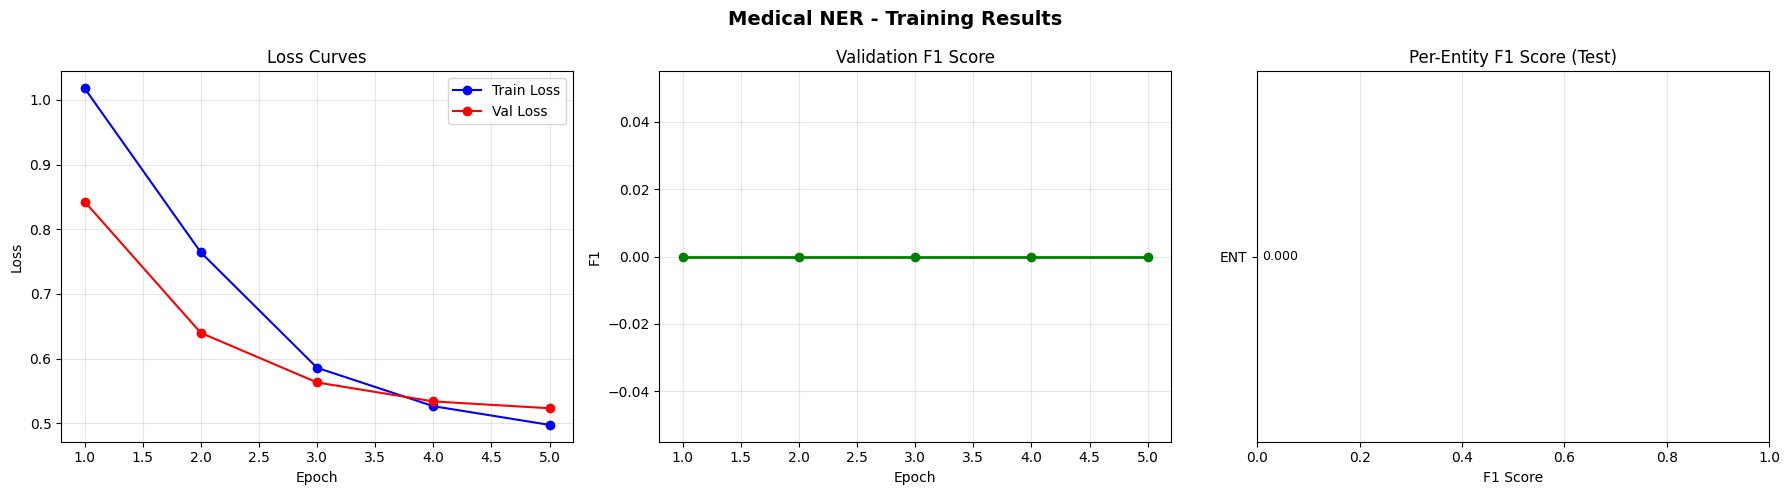

Plot saved: ner_results.png


In [ ]:
# ── 11. Visualizations ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Medical NER - Training Results", fontsize=14, fontweight="bold")

epochs_range = range(1, EPOCHS + 1)

# Plot 1: Loss curves
axes[0].plot(epochs_range, history["train_loss"], "b-o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation F1
axes[1].plot(epochs_range, history["val_f1"], "g-o", linewidth=2)
axes[1].set_title("Validation F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].grid(True, alpha=0.3)

# Plot 3: Per-Entity F1 (test set)
report = test_metrics["report"]
entity_names = [k for k in report.keys() if k not in ["micro avg", "macro avg", "weighted avg"]]
entity_f1s   = [report[k]["f1-score"] for k in entity_names]

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(entity_names)))
bars = axes[2].barh(entity_names, entity_f1s, color=colors)
axes[2].set_title("Per-Entity F1 Score (Test)")
axes[2].set_xlabel("F1 Score")
axes[2].set_xlim(0, 1.0)
for bar, val in zip(bars, entity_f1s):
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=9)
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("ner_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: ner_results.png")


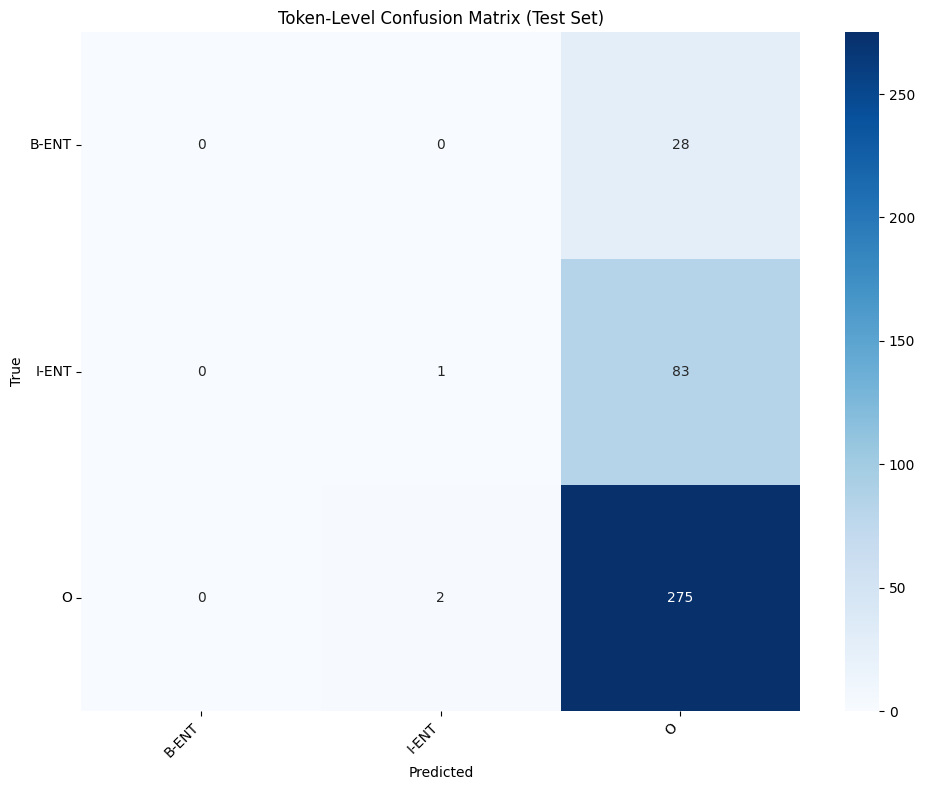

Confusion matrix saved: confusion_matrix.png


In [ ]:
# ── 12. Confusion Matrix per Token ───────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# جمع كل predictions وlabels على مستوى الـ token
best_model.eval()
all_preds_flat  = []
all_labels_flat = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        logits = best_model(input_ids=input_ids,
                            attention_mask=attention_mask).logits
        preds  = torch.argmax(logits, dim=-1)

        for p_seq, l_seq in zip(preds.cpu().numpy(), labels.cpu().numpy()):
            for p, l in zip(p_seq, l_seq):
                if l != -100:
                    all_preds_flat.append(p)
                    all_labels_flat.append(l)

# رسم confusion matrix
cm     = confusion_matrix(all_labels_flat, all_preds_flat)
labels_names = [id2label[i] for i in sorted(id2label.keys())]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)
plt.title("Token-Level Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved: confusion_matrix.png")


In [ ]:
# ── 13. Inference Demo ────────────────────────────────────────
from transformers import pipeline

print("\n" + "="*60)
print(" INFERENCE DEMO ".center(60, "="))
print("="*60)

ner_pipeline = pipeline(
    "ner",
    model=best_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1,
)

test_sentences = [
    "The patient was prescribed Metformin 500mg for Type 2 Diabetes.",
    "MRI scan revealed a tumor in the left frontal lobe of the brain.",
    "She was diagnosed with hypertension and prescribed Lisinopril.",
    "Patient shows symptoms of COVID-19 including fever and cough.",
]

for sentence in test_sentences:
    print(f"\nText: {sentence}")
    results = ner_pipeline(sentence)
    print("Entities found:")
    if results:
        for ent in results:
            print(f"  [{ent['entity_group']}] '{ent['word']}'  "
                  f"(score: {ent['score']:.3f})")
    else:
        print("  No entities detected.")



====================== INFERENCE DEMO ======================

Text: The patient was prescribed Metformin 500mg for Type 2 Diabetes.
Entities found:
  No entities detected.

Text: MRI scan revealed a tumor in the left frontal lobe of the brain.
Entities found:
  No entities detected.

Text: She was diagnosed with hypertension and prescribed Lisinopril.
Entities found:
  [ENT] '##nop'  (score: 0.461)

Text: Patient shows symptoms of COVID-19 including fever and cough.
Entities found:
  No entities detected.


In [ ]:
# ── 14. Final Summary ─────────────────────────────────────────
print("\n" + "="*60)
print(" FINAL SUMMARY ".center(60, "="))
print("="*60)
print(f"  Model           : {MODEL_NAME}")
print(f"  Dataset         : finalepoch/medical-ner")
print(f"  Train samples   : {len(train_data)}")
print(f"  Val samples     : {len(val_data)}")
print(f"  Test samples    : {len(test_data)}")
print(f"  Epochs trained  : {EPOCHS}")
print(f"  Best Val F1     : {best_f1:.4f}")
print(f"  Test F1         : {test_metrics['f1']:.4f}")
print(f"  Test Precision  : {test_metrics['precision']:.4f}")
print(f"  Test Recall     : {test_metrics['recall']:.4f}")
print(f"  Test Loss       : {test_loss:.4f}")
print(f"  Saved model at  : {best_model_path}/")
print("="*60)



====================== FINAL SUMMARY =======================
  Model           : dmis-lab/biobert-base-cased-v1.2
  Dataset         : finalepoch/medical-ner
  Train samples   : 24
  Val samples     : 3
  Test samples    : 4
  Epochs trained  : 5
  Best Val F1     : 0.0000
  Test F1         : 0.0000
  Test Precision  : 0.0000
  Test Recall     : 0.0000
  Test Loss       : 0.6518
  Saved model at  : best_medical_ner_model/


In [ ]:
# ── 15. Install and Download spaCy Model ────────────────────────
import subprocess
import sys

print("Installing spacy...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy", "spacy-lookups-data"])
print("Downloading en_core_web_sm model...")
subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

import spacy
print("SpaCy installed and model downloaded.")

Installing spacy...
SpaCy installed and model downloaded.


### 16. Prepare Data for spaCy Training

Now, I will convert the raw JSON data (which contains `content` and `annotations`) into spaCy's `DocBin` format. This format is optimized for training spaCy models. I will use the specific `tag_name`s from your annotations (e.g., 'Medicine', 'MedicalCondition') instead of a generic 'ENT' label, to enable more precise entity recognition.

In [ ]:
from spacy.tokens import DocBin
import random

# Initialize a blank English spaCy model (we only need the tokenizer)
nlp_blank = spacy.blank("en")

# Prepare data in spaCy's (text, annotations) format
spacy_training_data = []
for item in all_samples:
    text = item.get("content")
    entities = []
    if text and item.get("annotations"):
        for ann in item["annotations"]:
            start = ann.get("start")
            end = ann.get("end")
            label = ann.get("tag_name") # Use specific tag_name
            if start is not None and end is not None and label:
                entities.append((start, end, label))
        if entities:
            spacy_training_data.append((text, {"entities": entities}))

print(f"Total samples prepared for spaCy: {len(spacy_training_data)}")
print("Sample spaCy data entry:")
print(spacy_training_data[0])

# Split data into train, dev, and test sets
# Keeping the same split ratios as before
random.seed(42) # For reproducibility
random.shuffle(spacy_training_data)

total_samples = len(spacy_training_data)
train_size = int(0.8 * total_samples)
val_size   = int(0.1 * total_samples)
# test_size = total_samples - train_size - val_size

train_spacy_data = spacy_training_data[:train_size]
val_spacy_data   = spacy_training_data[train_size:train_size + val_size]
test_spacy_data  = spacy_training_data[train_size + val_size:]

print(f"SpaCy Train samples: {len(train_spacy_data)}")
print(f"SpaCy Val samples:   {len(val_spacy_data)}")
print(f"SpaCy Test samples:  {len(test_spacy_data)}")

# Convert to DocBin format
def create_docbin(data, nlp_obj):
    db = DocBin()
    for text, annotations in data:
        doc = nlp_obj.make_doc(text)
        ents = []
        for start, end, label in annotations["entities"]:
            span = doc.char_span(start, end, label=label, alignment_mode="contract")
            if span is not None:
                ents.append(span)
            else:
                # Handle potential alignment issues if char_span returns None
                print(f"Skipping entity due to alignment issue: '{text[start:end]}' for text: '{text}'")
        try:
            doc.ents = ents
            db.add(doc)
        except ValueError as e:
            print(f"Could not set entities for doc: {text}. Error: {e}")
    return db

train_db = create_docbin(train_spacy_data, nlp_blank)
val_db   = create_docbin(val_spacy_data, nlp_blank)
test_db  = create_docbin(test_spacy_data, nlp_blank)

# Save DocBin files
train_db.to_disk("train.spacy")
val_db.to_disk("dev.spacy") # spacy train expects 'dev.spacy' for validation
test_db.to_disk("test.spacy")

print("SpaCy DocBin files saved: train.spacy, dev.spacy, test.spacy")

Total samples prepared for spaCy: 30
Sample spaCy data entry:
("While bismuth compounds (Pepto-Bismol) decreased the number of bowel movements in those with travelers' diarrhea, they do not decrease the length of illness.[91] Anti-motility agents like loperamide are also effective at reducing the number of stools but not the duration of disease.[8] These agents should be used only if bloody diarrhea is not present.[92]\n\nDiosmectite, a natural aluminomagnesium silicate clay, is effective in alleviating symptoms of acute diarrhea in children,[93] and also has some effects in chronic functional diarrhea, radiation-induced diarrhea, and chemotherapy-induced diarrhea.[45] Another absorbent agent used for the treatment of mild diarrhea is kaopectate.\n\nRacecadotril an antisecretory medication may be used to treat diarrhea in children and adults.[86] It has better tolerability than loperamide, as it causes less constipation and flatulence.[94]", {'entities': [(360, 371, 'Medicine'), (383, 

### 17. Generate spaCy Training Configuration

To train a spaCy model, we need a configuration file (`config.cfg`). I'll use `spacy init config` to generate a base configuration file, specifically for Named Entity Recognition (NER), using a blank English model as the base and optimizing for accuracy. This will create a `base_config.cfg` file that you can inspect and modify if needed.

In [ ]:
print("Generating spaCy base config file...")
subprocess.run([sys.executable, "-m", "spacy", "init", "config", "base_config.cfg", "--lang", "en", "--pipeline", "ner", "--optimize", "accuracy", "--force"], check=True)
print("Base config generated: base_config.cfg")

# Display the generated config file content (optional)
with open("base_config.cfg", "r", encoding="utf-8") as f:
    print("\n--- base_config.cfg ---")
    print(f.read())
    print("----------------------")

Generating spaCy base config file...
Base config generated: base_config.cfg

--- base_config.cfg ---
[paths]
train = null
dev = null
vectors = "en_core_web_lg"
init_tok2vec = null

[system]
gpu_allocator = null
seed = 0

[nlp]
lang = "en"
pipeline = ["tok2vec", "ner"]
batch_size = 1000
disabled = []
before_creation = null
after_creation = null
after_pipeline_creation = null

[corpora]

[training]
dev_corpus = "corpora.dev"
train_corpus = "corpora.train"
seed = ${system.seed}
gpu_allocator = ${system.gpu_allocator}
dropout = 0.1
accumulate_gradient = 1
patience = 1600
max_epochs = 0
max_steps = 20000
eval_frequency = 200
frozen_components = []
annotating_components = []
before_to_disk = null
before_update = null

[initialize]
vectors = ${paths.vectors}
init_tok2vec = ${paths.init_tok2vec}
vocab_data = null
lookups = null
before_init = null
after_init = null

[components]

[pretraining]

[nlp.tokenizer]
@tokenizers = "spacy.Tokenizer.v1"

[nlp.vectors]
@vectors = "spacy.Vectors.v1"

[cor

In [ ]:
# Download en_core_web_lg model as required by base_config.cfg
print("Downloading en_core_web_lg model...")
subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_lg"])
print("en_core_web_lg model downloaded.")

en_core_web_lg model downloaded.


### 18. Train spaCy NER Model

Now that the data is prepared and the configuration file is generated, we can train the spaCy NER model. This command will take the `train.spacy` and `dev.spacy` files, and the `base_config.cfg` file, to train a new NER model. The trained model will be saved to the `output` directory.

In [ ]:
import subprocess
import sys
import torch # Ensure torch is imported for torch.cuda.is_available()

print("Starting spaCy NER model training...")
try:
    # Check if GPU is available and print device info
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        gpu_id = "0"
    else:
        print("Using CPU (GPU not available or not enabled).")
        gpu_id = "-1"

    result = subprocess.run([
        sys.executable, "-m", "spacy", "train",
        "base_config.cfg",
        "--output", "output",
        "--paths.train", "train.spacy",
        "--paths.dev", "dev.spacy",
        "--gpu-id", gpu_id, # Use GPU if available
    ], check=True, capture_output=True, text=True, encoding='utf-8')
    print(result.stdout)
    print(result.stderr)
    print("SpaCy NER model training complete. Model saved to 'output' directory.")
except subprocess.CalledProcessError as e:
    print(f"Error during spaCy training: {e}")
    print(f"Stdout: {e.stdout}")
    print(f"Stderr: {e.stderr}")
    raise # Re-raise the exception to clearly show the failure

Starting spaCy NER model training...
Using GPU: Tesla T4


KeyboardInterrupt: 

### Adjusting spaCy Training Configuration for Speed

To speed up training, especially for a small dataset, we can reduce the `max_steps` parameter in the `base_config.cfg` file. The current value is 20,000 steps. We'll change it to 2,000 for quicker iterations during development.

In [ ]:
import re

config_file_path = "base_config.cfg"

with open(config_file_path, "r", encoding="utf-8") as f:
    config_content = f.read()

# Reduce max_steps from 20000 to 2000 for faster experimentation
# This also reduces eval_frequency proportionally to still evaluate frequently over fewer steps
# Make sure to reset it for final training if needed
config_content = re.sub(r"max_steps = 20000", "max_steps = 2000", config_content)
config_content = re.sub(r"eval_frequency = 200", "eval_frequency = 20", config_content)

with open(config_file_path, "w", encoding="utf-8") as f:
    f.write(config_content)

print(f"Modified {config_file_path}: max_steps reduced to 2000 and eval_frequency to 20.")

# Display the modified config file content (optional)
with open(config_file_path, "r", encoding="utf-8") as f:
    print("\n--- Modified base_config.cfg ---")
    print(f.read())
    print("--------------------------------")

Modified base_config.cfg: max_steps reduced to 2000 and eval_frequency to 20.

--- Modified base_config.cfg ---
[paths]
train = null
dev = null
vectors = "en_core_web_lg"
init_tok2vec = null

[system]
gpu_allocator = null
seed = 0

[nlp]
lang = "en"
pipeline = ["tok2vec", "ner"]
batch_size = 1000
disabled = []
before_creation = null
after_creation = null
after_pipeline_creation = null

[corpora]

[training]
dev_corpus = "corpora.dev"
train_corpus = "corpora.train"
seed = ${system.seed}
gpu_allocator = ${system.gpu_allocator}
dropout = 0.1
accumulate_gradient = 1
patience = 1600
max_epochs = 0
max_steps = 2000
eval_frequency = 20
frozen_components = []
annotating_components = []
before_to_disk = null
before_update = null

[initialize]
vectors = ${paths.vectors}
init_tok2vec = ${paths.init_tok2vec}
vocab_data = null
lookups = null
before_init = null
after_init = null

[components]

[pretraining]

[nlp.tokenizer]
@tokenizers = "spacy.Tokenizer.v1"

[nlp.vectors]
@vectors = "spacy.Vectors.

After ensuring you've switched to a GPU runtime and executed the cell above to modify the `base_config.cfg`, you can now re-run the spaCy training cell (the one you just interrupted) to see if the training finishes faster.